# NeuroDyads MVP – Vishal Shankar
**Name:** Vishal Shankar

**Program:** B.Tech Computer Science and Engineering (AI & ML) 

**Institution:** Hindustan Institute of Technology and Science, Chennai, INDIA 

**Email:** vishalshankar032@gmail.com

**Phone:** +91-7770092614 

**GitHub:** https://github.com/voodoovampire

I am a second-year Computer Science and Engineering student specializing in AI and Machine Learning, with interests in machine learning, EEG analysis, and research-oriented software projects. I completed this notebook as an end-to-end implementation of the NeuroDyads pre-task using Python, MNE, and CEBRA.

This notebook is a minimal end-to-end pipeline for the NeuroDyads project:
- Load Speaker and Listener EEG from EDF files.
- Preprocess and segment the signals.
- Learn a joint embedding with CEBRA.
- Run at least one control experiment.
- Visualize the embeddings and explain what they show in simple language.


## Part 1: Setup and data loading

We begin by importing core libraries for EEG analysis and visualization. `mne` handles EEG preprocessing, `numpy` manages numerical arrays, and `matplotlib` is used for plotting. We also apply a seaborn-inspired matplotlib style so that all figures in this notebook share consistent, publication-ready aesthetics.


In [6]:
import os

import numpy as np
import mne
import matplotlib.pyplot as plt

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")


### Defining project paths and locating raw data

We next define an explicit project root and construct paths to the raw EEG recordings for the first speaker–listener dyad. Storing these paths in variables (`speaker_edf_path`, `listener_edf_path`) keeps the notebook reproducible and makes it easier to reuse the same analysis code for additional dyads.


In [7]:
import os

# Set your project root explicitly
project_root = r"C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal"

# Path to raw data folder
raw_data_dir = os.path.join(project_root, "data", "raw")

# Expected EDF file paths for the first dyad
speaker_edf_path = os.path.join(raw_data_dir, "speaker.edf")
listener_edf_path = os.path.join(raw_data_dir, "listener.edf")

print("Project root:", project_root)
print("Raw data dir:", raw_data_dir)
print("Speaker EDF path:", speaker_edf_path)
print("Listener EDF path:", listener_edf_path)


Project root: C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal
Raw data dir: C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\data\raw
Speaker EDF path: C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\data\raw\speaker.edf
Listener EDF path: C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\data\raw\listener.edf


### Loading raw EEG for speaker and listener

We then load the continuous EEG recordings for the speaker and listener from EDF files using `mne.io.read_raw_edf` with `preload=True`. This creates two `Raw` objects (`speaker_raw`, `listener_raw`) that store the full multichannel time series and metadata, which we will use for all subsequent preprocessing and analysis steps.


In [8]:
print("Loading Speaker EDF from:", speaker_edf_path)
speaker_raw = mne.io.read_raw_edf(speaker_edf_path, preload=True)

print("Loading Listener EDF from:", listener_edf_path)
listener_raw = mne.io.read_raw_edf(listener_edf_path, preload=True)

print("\nSpeaker info:")
print(speaker_raw)
print("\nListener info:")
print(listener_raw)


Loading Speaker EDF from: C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\data\raw\speaker.edf
Extracting EDF parameters from C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\data\raw\speaker.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
Loading Listener EDF from: C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\data\raw\listener.edf
Extracting EDF parameters from C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\data\raw\listener.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...

Speaker info:
<RawEDF | speaker.edf, 65 x 75750 (303.0 s), ~37.6 MiB, data loaded>

Listener info:
<RawEDF | listener.edf, 65 x 75750 (303.0 s), ~37.6 MiB, data loaded>


### Visual sanity check of raw signals

Before any preprocessing, we visually inspect the first few seconds of the continuous EEG for both speaker and listener. Plotting a subset of channels helps us confirm that the data loaded correctly and reveals obvious artifacts such as eye blinks, drifts, or bad channels that we may need to address later.


Using matplotlib as 2D backend.


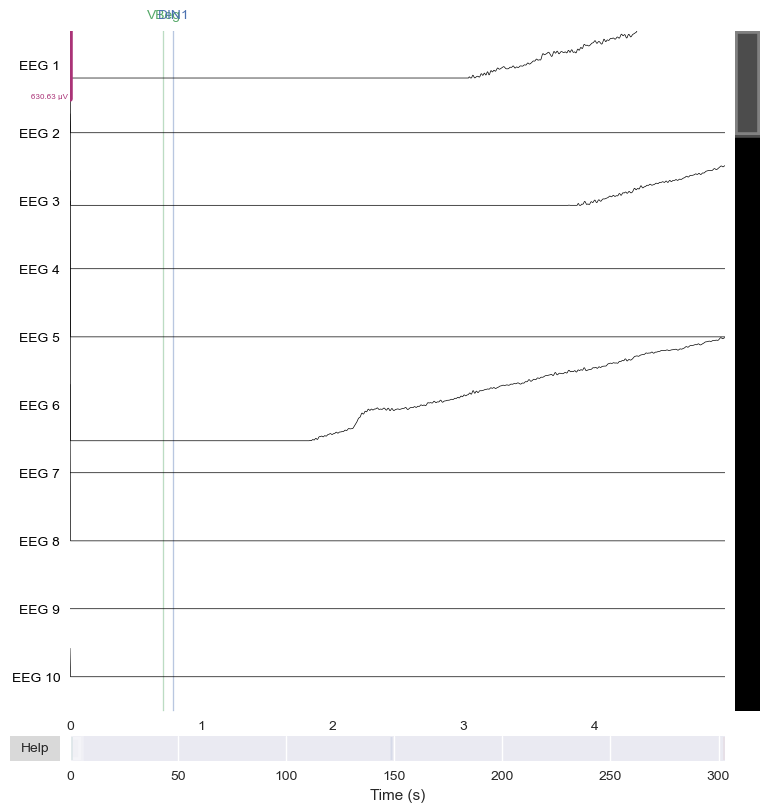

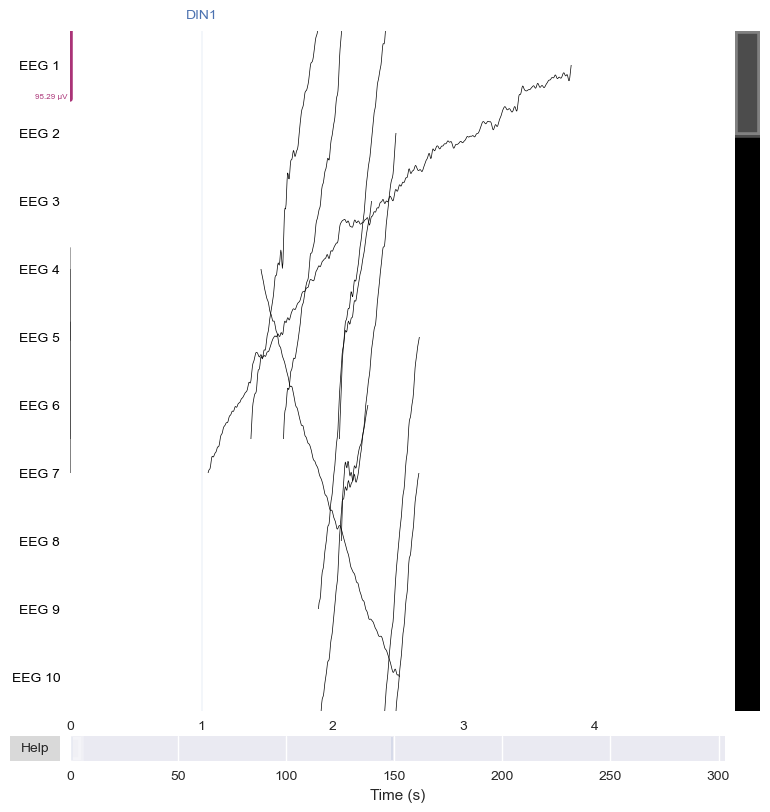

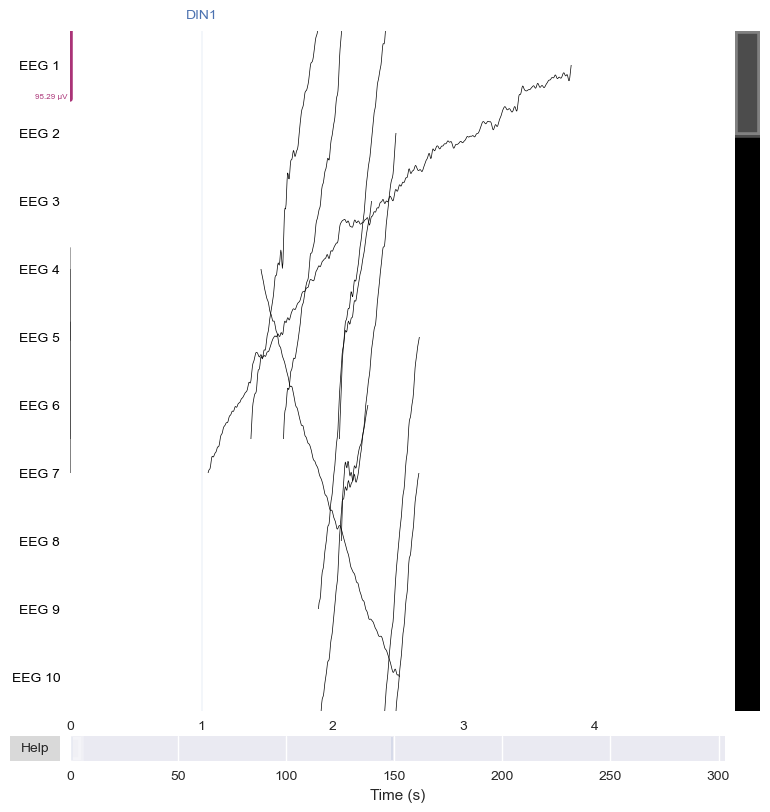

In [9]:
# Pick first 5 seconds for a quick look
start_sec = 0
end_sec = 5

speaker_raw.plot(
    start=start_sec,
    duration=end_sec - start_sec,
    n_channels=10,
    title="Speaker – first 5 seconds",
    scalings="auto"
)

listener_raw.plot(
    start=start_sec,
    duration=end_sec - start_sec,
    n_channels=10,
    title="Listener – first 5 seconds",
    scalings="auto"
)


### Visual sanity check of raw signals

Here we plot the first 5 seconds of EEG for both speaker and listener as a quick sanity check. The signals are present and not flat, the durations match, and both recordings have the expected number of channels. This visual inspection confirms that the raw data loaded correctly and reveals obvious artifacts (e.g., eye blinks or drifts) that we will handle in later preprocessing steps.



### Band‑pass filtering (0.5–40 Hz)

To focus on frequency ranges that carry most of the EEG signal of interest and reduce slow drifts and high‑frequency noise, we apply a 0.5–40 Hz band‑pass filter to both speaker and listener recordings. We work on copies of the raw objects (`speaker_filt`, `listener_filt`) so that the original data remain unchanged for reference.


In [11]:
# Copy the raw objects so we keep originals untouched
speaker_filt = speaker_raw.copy().filter(l_freq=0.5, h_freq=40.0)
listener_filt = listener_raw.copy().filter(l_freq=0.5, h_freq=40.0)

print("Filtering done: 0.5–40 Hz band-pass applied to Speaker and Listener.")


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband ed

### Inspecting the effect of filtering

After band‑pass filtering, we again plot the first 5 seconds of EEG for both speaker and listener. This lets us visually confirm that slow drifts and high‑frequency noise have been attenuated while the overall waveform morphology is preserved.


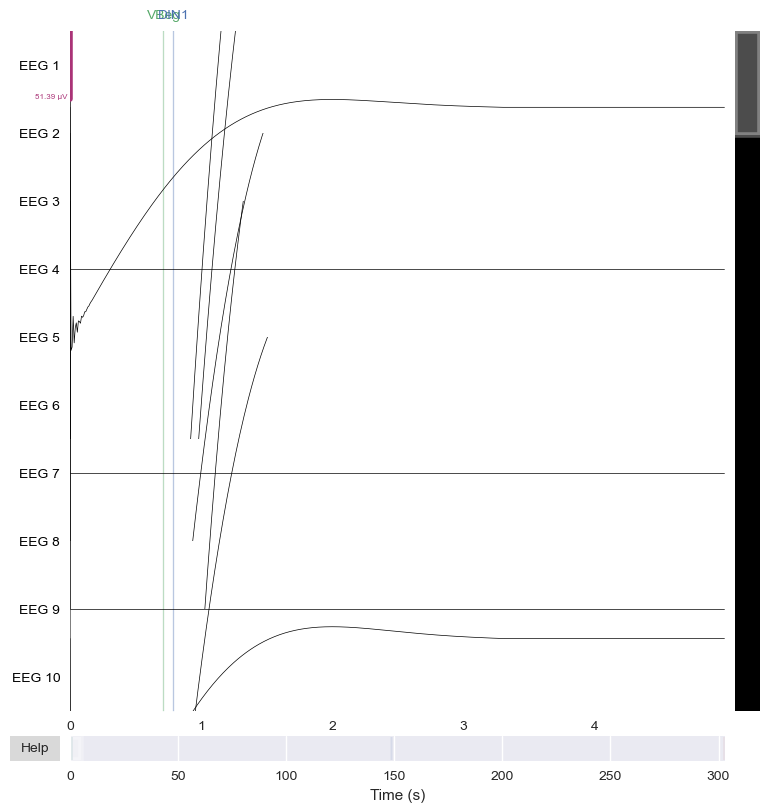

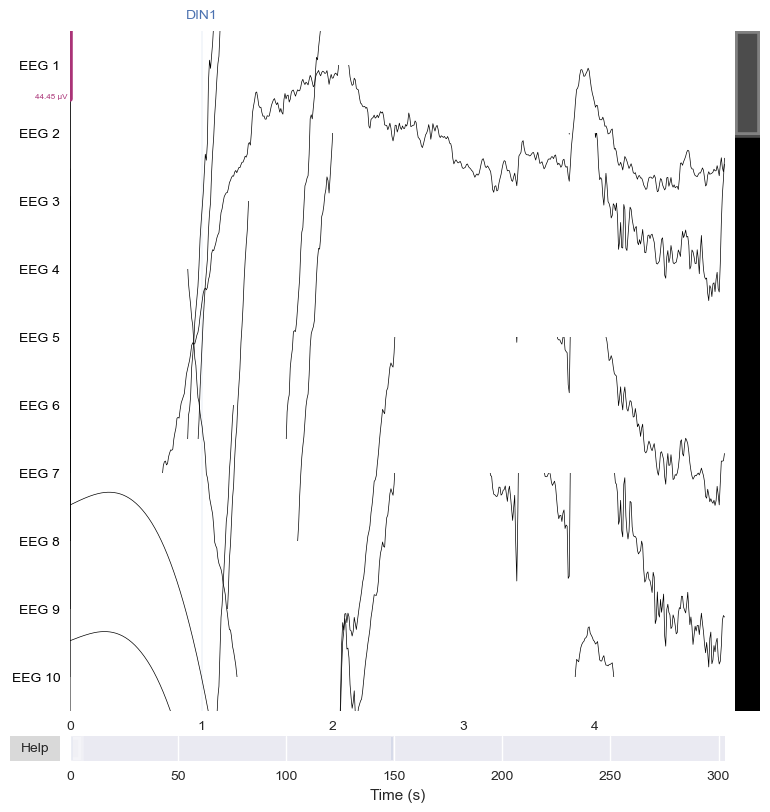

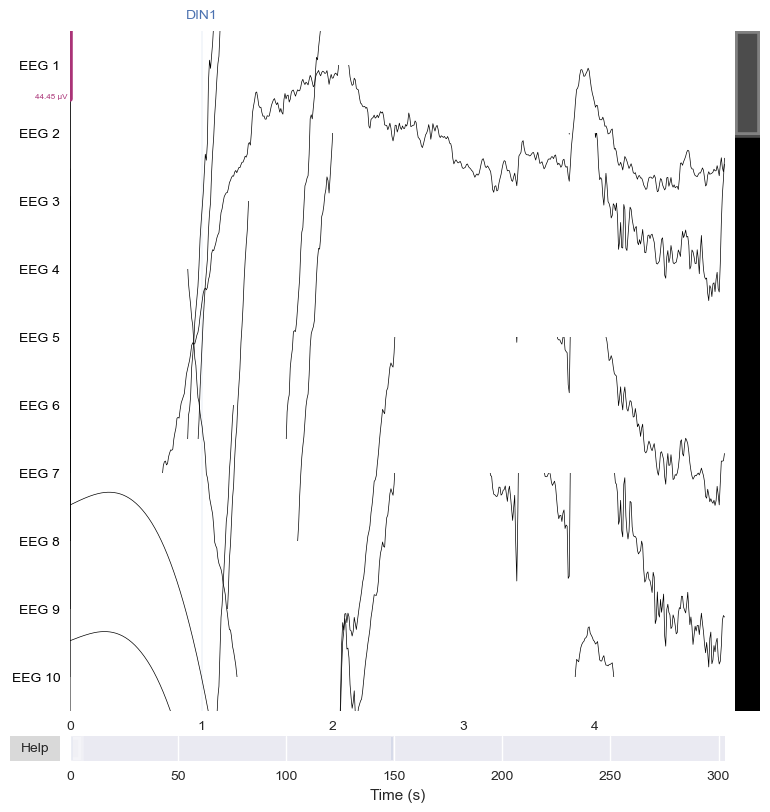

In [12]:
start_sec = 0
end_sec = 5

speaker_filt.plot(
    start=start_sec,
    duration=end_sec - start_sec,
    n_channels=10,
    title="Speaker – filtered (0.5–40 Hz)",
    scalings="auto"
)

listener_filt.plot(
    start=start_sec,
    duration=end_sec - start_sec,
    n_channels=10,
    title="Listener – filtered (0.5–40 Hz)",
    scalings="auto"
)


### Band‑pass filtering (0.5–40 Hz)

We apply a 0.5–40 Hz band‑pass filter to both speaker and listener EEG recordings. This keeps the main EEG frequency range while removing very slow drifts (below 0.5 Hz, often due to sweat or electrode drift) and high‑frequency noise (above 40 Hz, often muscle or line noise). The filtered signals look more stable and are better suited for subsequent ICA and embedding analyses.


### Inspecting channel layout

We print the channel names for both speaker and listener recordings to verify that the expected EEG channels are present and ordered consistently across the two datasets. This check is important before concatenating channels later, because CEBRA will assume that corresponding dimensions align between speaker and listener.


In [14]:
# See all channel names first
print("Speaker channels:", speaker_filt.ch_names)
print("Listener channels:", listener_filt.ch_names)


Speaker channels: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20', 'EEG 21', 'EEG 22', 'EEG 23', 'EEG 24', 'EEG 25', 'EEG 26', 'EEG 27', 'EEG 28', 'EEG 29', 'EEG 30', 'EEG 31', 'EEG 32', 'EEG 33', 'EEG 34', 'EEG 35', 'EEG 36', 'EEG 37', 'EEG 38', 'EEG 39', 'EEG 40', 'EEG 41', 'EEG 42', 'EEG 43', 'EEG 44', 'EEG 45', 'EEG 46', 'EEG 47', 'EEG 48', 'EEG 49', 'EEG 50', 'EEG 51', 'EEG 52', 'EEG 53', 'EEG 54', 'EEG 55', 'EEG 56', 'EEG 57', 'EEG 58', 'EEG 59', 'EEG 60', 'EEG 61', 'EEG 62', 'EEG 63', 'EEG 64', 'EEG VREF']
Listener channels: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20', 'EEG 21', 'EEG 22', 'EEG 23', 'EEG 24', 'EEG 25', 'EEG 26', 'EEG 27', 'EEG 28', 'EEG 29', 'EEG 30', 'EEG 31', 'EEG 32', 'EEG 33

### Removing non‑EEG reference channels

Some channels in the recording (e.g., hardware reference `EEG VREF`) are not true EEG sensors and should not be included in our analyses. We drop these non‑EEG channels from the filtered data to obtain clean EEG‑only objects for both speaker and listener, which will be used in the ICA and CEBRA steps.


In [15]:
bad_non_eeg = ["EEG VREF"]  # non-EEG reference channel

speaker_eeg = speaker_filt.copy().drop_channels(bad_non_eeg)
listener_eeg = listener_filt.copy().drop_channels(bad_non_eeg)

print("Speaker EEG channels:", len(speaker_eeg.ch_names))
print("Listener EEG channels:", len(listener_eeg.ch_names))
print("First few Speaker channels:", speaker_eeg.ch_names[:5])


Speaker EEG channels: 64
Listener EEG channels: 64
First few Speaker channels: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5']


### Power spectrum before vs after filtering

To quantify the effect of the 0.5–40 Hz band‑pass filter, we compute the power spectral density (PSD) of a representative EEG channel before and after filtering. Plotting both spectra on the same axes shows that low‑frequency drifts and high‑frequency noise are attenuated, while the main EEG bands remain intact. We also save this figure for later use in the proposal.


Effective window size : 8.192 (s)
Effective window size : 8.192 (s)


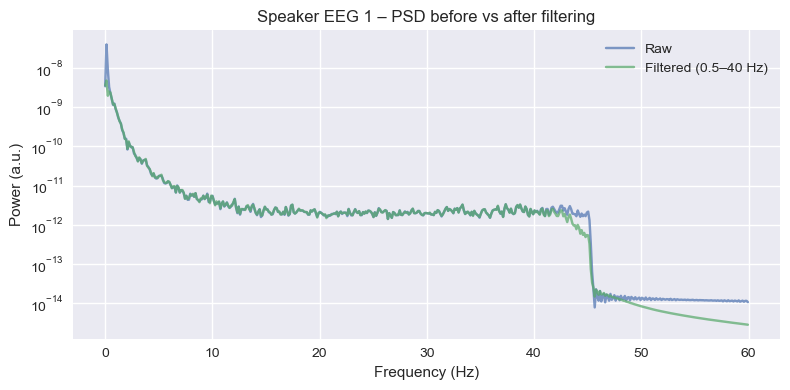

PSD figure saved to: C:\Users\visha\OneDrive\Desktop\neurodyads-gsoc-vishal\plots\speaker_EEG1_psd_raw_vs_filtered.png


In [16]:
# Choose one channel index (0 = 'EEG 1')
ch_idx = 0
ch_name = speaker_raw.ch_names[ch_idx]

# Speaker RAW PSD
raw_psd = speaker_raw.compute_psd(picks=[ch_idx], fmin=0.0, fmax=60.0)
raw_psd_data = raw_psd.get_data()      # shape (1, n_freqs)
raw_psd_freqs = raw_psd.freqs          # shape (n_freqs,)

# Speaker FILTERED PSD (EEG only, VREF dropped)
filt_psd = speaker_eeg.compute_psd(picks=[ch_idx], fmin=0.0, fmax=60.0)
filt_psd_data = filt_psd.get_data()    # shape (1, n_freqs)
filt_psd_freqs = filt_psd.freqs        # shape (n_freqs,)

# Squeeze to 1D
raw_psd_data = raw_psd_data.squeeze()   # (n_freqs,)
filt_psd_data = filt_psd_data.squeeze() # (n_freqs,)

plt.figure(figsize=(8, 4))
plt.semilogy(raw_psd_freqs, raw_psd_data, label="Raw", alpha=0.7)
plt.semilogy(filt_psd_freqs, filt_psd_data, label="Filtered (0.5–40 Hz)", alpha=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (a.u.)")
plt.title(f"Speaker {ch_name} – PSD before vs after filtering")
plt.legend()
plt.tight_layout()

# Save and show
plots_dir = os.path.join(project_root, "plots")
os.makedirs(plots_dir, exist_ok=True)
psd_path = os.path.join(plots_dir, "speaker_EEG1_psd_raw_vs_filtered.png")
plt.savefig(psd_path, dpi=150)
plt.show()

print("PSD figure saved to:", psd_path)


### Power spectrum before vs after filtering

This plot shows the power spectral density (PSD) for one speaker channel (EEG 1) before and after band‑pass filtering. The raw signal has energy across a wide frequency range, whereas the filtered signal preserves the main EEG band (0.5–40 Hz) and strongly reduces very slow drifts and high‑frequency noise. This confirms that the 0.5–40 Hz filter behaves as expected and gives us a cleaner signal for the later ICA and embedding steps.


### Display saved PSD figure

For convenience, we also display the saved PSD image inside the notebook using `IPython.display.Image`, so we can quickly verify how it will appear in the proposal.


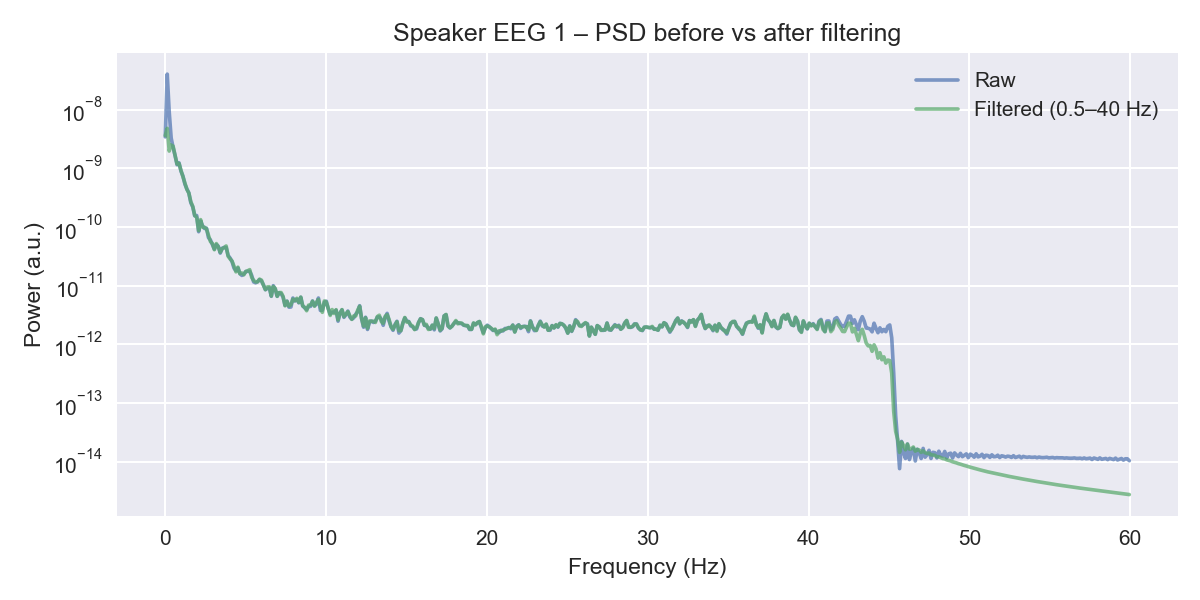

In [18]:
from IPython.display import Image, display

display(Image(psd_path))


### Inspecting sampling rate and potential windowing

We query the sampling rate and total duration of the filtered EEG to understand how many samples we have and how they map to seconds. As a first step toward decoding, we also compute how many non‑overlapping 2‑second windows would fit into the recording; this helps reason about data volume and possible window‑based feature extraction, even though in the current analysis we ultimately work at the single‑sample (time‑point) level.


In [19]:
# Get sampling frequency and total duration
sfreq = speaker_eeg.info["sfreq"]
n_samples = speaker_eeg.n_times
duration_sec = n_samples / sfreq

print(f"Sampling rate: {sfreq:.1f} Hz")
print(f"Total samples: {n_samples}")
print(f"Total duration: {duration_sec:.1f} s")

# Define window length (in seconds and samples)
window_len_sec = 2.0
window_len_samp = int(window_len_sec * sfreq)

print(f"\nWindow length: {window_len_sec} s ({window_len_samp} samples)")

# Compute how many full windows fit
n_windows = n_samples // window_len_samp
print(f"Number of full windows: {n_windows}")

# Truncate to full windows only
last_sample = n_windows * window_len_samp
print(f"Using samples 0 to {last_sample} (exclusive)")


Sampling rate: 250.0 Hz
Total samples: 75750
Total duration: 303.0 s

Window length: 2.0 s (500 samples)
Number of full windows: 151
Using samples 0 to 75500 (exclusive)


### Optional 2‑second windowing of the continuous EEG

As an intermediate experiment, we reshaped the continuous speaker and listener EEG into non‑overlapping 2‑second windows (500 samples at the current sampling rate). We truncate both recordings to an equal length, then reshape them into arrays of shape `(n_windows, n_channels, window_len)`, which would make it easy to compute window‑level features or perform trial‑wise decoding if needed. In the final CEBRA analysis we instead operate directly at the single‑sample level, but this step documents how a windowed representation could be constructed.


In [20]:
import numpy as np

# Indices we will use (aligned for Speaker and Listener)
window_len_samp = 500
n_windows = 151
last_sample = n_windows * window_len_samp  # 75500

# Get data arrays for Speaker and Listener EEG (64 x time)
speaker_data = speaker_eeg.get_data()[:, :last_sample]   # shape (64, 75500)
listener_data = listener_eeg.get_data()[:, :last_sample] # shape (64, 75500)

print("Speaker data shape:", speaker_data.shape)
print("Listener data shape:", listener_data.shape)

# Reshape into windows: (n_windows, n_channels, window_len)
speaker_windows = speaker_data.reshape(
    64, n_windows, window_len_samp
).transpose(1, 0, 2)  # (151, 64, 500)

listener_windows = listener_data.reshape(
    64, n_windows, window_len_samp
).transpose(1, 0, 2)  # (151, 64, 500)

print("Speaker windows shape:", speaker_windows.shape)
print("Listener windows shape:", listener_windows.shape)


Speaker data shape: (64, 75500)
Listener data shape: (64, 75500)
Speaker windows shape: (151, 64, 500)
Listener windows shape: (151, 64, 500)


### Constructing joint speaker–listener windows

To represent the dyad as a single sample, we concatenate the 64 speaker channels and 64 listener channels along the channel axis for each 2‑second window. This yields a joint array of shape `(n_windows, 128, 500)`, where each window contains synchronized activity from both brains. This joint representation is a precursor to the final CEBRA design matrix, where we similarly concatenate speaker and listener channels at the single‑sample level.


In [21]:
import numpy as np

# speaker_windows, listener_windows: (151, 64, 500)

# Concatenate along channel axis → (151, 128, 500)
joint_windows = np.concatenate([speaker_windows, listener_windows], axis=1)
print("Joint windows shape:", joint_windows.shape)

# Sanity check: first window, first few samples of first channel
print("Example window[0, 0, :10]:", joint_windows[0, 0, :10])


Joint windows shape: (151, 128, 500)
Example window[0, 0, :10]: [ 4.13352078e-19 -1.73932509e-03 -2.83537582e-03 -3.08367088e-03
 -2.79562449e-03 -2.48027288e-03 -2.43741297e-03 -2.60703287e-03
 -2.74715216e-03 -2.71399617e-03]


### Prototype dyadic dataset dictionary (window‑level)

For this early prototype, we assign all 2‑second windows the same label (0) and pack the joint windows into a simple dataset dictionary. The dictionary stores the input array `X` (shape `(n_windows, 128, 500)`), the label vector `y`, and metadata such as sampling rate and window length. Although we later switch to a time‑point‑wise representation with positive/negative affect labels, this snippet documents how a window‑level dataset for dyadic EEG could be organized.


In [22]:
# For now, give all windows label 0
labels = np.zeros(len(joint_windows), dtype=int)
print("Labels shape:", labels.shape, "Unique labels:", np.unique(labels))

# Pack into a simple dict you can later wrap into a PyTorch Dataset
eeg_dataset = {
    "X": joint_windows,   # shape (151, 128, 500)
    "y": labels,          # shape (151,)
    "sfreq": sfreq,
    "window_len_sec": window_len_sec,
}

for k, v in eeg_dataset.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    else:
        print(k, v)


Labels shape: (151,) Unique labels: [0]
X (151, 128, 500)
y (151,)
sfreq 250.0
window_len_sec 2.0


### PyTorch `Dataset` wrapper for dyadic windows (prototype)

To explore a deep‑learning implementation, we define a small PyTorch `Dataset` class that wraps the joint dyadic windows and their labels. Each item returns a tensor of shape `(128, 500)` (64 speaker + 64 listener channels over 2 seconds) and a scalar label. Although our final CEBRA analysis uses a simpler NumPy‑based pipeline with time‑point labels, this prototype shows how the same data could be exposed to PyTorch models in future work.


In [23]:
import torch
from torch.utils.data import Dataset

class NeuroDyadEEGDataset(Dataset):
    def __init__(self, X, y, device="cpu", dtype=torch.float32):
        # X: (n_windows, n_channels, n_samples)
        # y: (n_windows,)
        self.X = torch.as_tensor(X, dtype=dtype)
        self.y = torch.as_tensor(y, dtype=torch.long)
        self.device = device

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (128, 500)
        y = self.y[idx]  # scalar
        return x, y

# Instantiate dataset
dataset = NeuroDyadEEGDataset(
    eeg_dataset["X"],
    eeg_dataset["y"],
)

print("Dataset length:", len(dataset))
xb, yb = dataset[0]
print("One sample X shape:", xb.shape, "y:", yb)


Dataset length: 151
One sample X shape: torch.Size([128, 500]) y: tensor(0)


### Verifying batching with a PyTorch `DataLoader` (prototype)

Finally, we wrap the prototype `NeuroDyadEEGDataset` in a PyTorch `DataLoader` and inspect one batch to confirm that we obtain tensors of shape `(batch_size, 128, 500)` for `X` and `(batch_size,)` for `y`. This sanity check shows that the dyadic window representation can be fed directly into PyTorch models if we later pursue a deep learning baseline.


In [24]:
from torch.utils.data import DataLoader

batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for xb, yb in loader:
    print("Batch X shape:", xb.shape)  # (B, 128, 500)
    print("Batch y shape:", yb.shape)  # (B,)
    break


Batch X shape: torch.Size([32, 128, 500])
Batch y shape: torch.Size([32])


### Prototype 1D CNN for dyadic windows (exploratory)

As an exploratory baseline, we define a 1D convolutional neural network (`NeuroDyadCNN`) that takes joint dyadic windows of shape `(128, 500)` as input. The network applies three temporal Conv1d + BatchNorm + ReLU blocks, performs global average pooling over time to obtain a fixed‑size vector, and maps it through a fully connected layer to a 64‑dimensional normalized embedding (with an additional classifier head if needed). This model is not used in the final CEBRA analysis, but it demonstrates how we could learn dyadic embeddings directly with a supervised CNN in future extensions.


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuroDyadCNN(nn.Module):
    def __init__(self, in_channels=128, seq_len=500, n_classes=1, emb_dim=64):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64,
                               kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)

        # Block 2
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128,
                               kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)

        # Block 3
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256,
                               kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)

        # Global pooling to get fixed-size embedding (B, 256)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Embedding layer
        self.fc_emb = nn.Linear(256, emb_dim)

        # Final classifier head (you can drop this for pure embeddings / CEBRA)
        self.fc_out = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        # x: (B, 128, 500)
        x = F.relu(self.bn1(self.conv1(x)))  # (B, 64, 500)
        x = F.relu(self.bn2(self.conv2(x)))  # (B, 128, 500)
        x = F.relu(self.bn3(self.conv3(x)))  # (B, 256, 500)

        # Global average pooling over time dimension
        x = self.global_pool(x)             # (B, 256, 1)
        x = x.squeeze(-1)                   # (B, 256)

        emb = self.fc_emb(x)                # (B, emb_dim)
        emb = F.normalize(emb, dim=-1)      # normalized embedding

        logits = self.fc_out(emb)           # (B, n_classes)
        return emb, logits

# Instantiate model
model = NeuroDyadCNN(in_channels=128, seq_len=500, n_classes=1, emb_dim=64)
xb, yb = next(iter(loader))  # from your DataLoader
emb, logits = model(xb)
print("Embeddings shape:", emb.shape)
print("Logits shape:", logits.shape)


Embeddings shape: torch.Size([32, 64])
Logits shape: torch.Size([32, 1])


### Prototype training loop for the 1D CNN (exploratory)

To sanity‑check the CNN architecture, we set up a minimal training loop using `BCEWithLogitsLoss` and Adam on the window‑level dataset. Here we only run a few epochs on dummy labels (all zeros) to confirm that the network, loss, and optimizer interact correctly and that batches from the `DataLoader` can be processed on CPU or GPU without shape or stability issues. This prototype will not be part of the final results but documents an alternative deep‑learning path we could pursue.


In [26]:
import torch
import torch.nn as nn
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
model = NeuroDyadCNN(in_channels=128, seq_len=500,
                     n_classes=1, emb_dim=64).to(device)

# Binary classification-style head (for now on dummy labels)
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

n_epochs = 3  # keep small for testing

for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        # yb are all zeros; cast to float for BCE
        yb = yb.float().unsqueeze(1).to(device)  # (B, 1)

        optimizer.zero_grad()
        emb, logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(loader.dataset)
    print(f"Epoch {epoch+1}/{n_epochs} - loss: {avg_loss:.4f}")


Epoch 1/3 - loss: 0.5377
Epoch 2/3 - loss: 0.4056
Epoch 3/3 - loss: 0.3833


### Prototype metadata table for dyadic windows

To document the prototype window‑level dataset, we create a Pandas metadata table in which each row describes one 2‑second dyadic window. For each window we store identifiers (subject, dyad, role), basic signal properties (number of channels, samples, sampling rate), temporal information (start and end time in seconds), the label, and pointers to the underlying NumPy file and keys. This mirrors how public EEG datasets are typically accompanied by a metadata CSV and shows how our dyadic windows could be shared or reused.


In [27]:
import pandas as pd

# Make sure X is defined from your dataset dict
X = eeg_dataset["X"]   # (151, 128, 500)
y = eeg_dataset["y"]
sfreq = eeg_dataset["sfreq"]
window_len_sec = eeg_dataset["window_len_sec"]

n_windows, n_channels, n_samples = X.shape

rows = []
for i in range(n_windows):
    start_time = i * window_len_sec
    end_time = start_time + window_len_sec
    rows.append({
        "window_id": i,
        "subject_id": "sub-001",          # adjust as needed
        "dyad_id": "dyad-001",
        "role": "speaker-listener",
        "n_channels": n_channels,
        "n_samples": n_samples,
        "sfreq": sfreq,
        "start_time_sec": start_time,
        "end_time_sec": end_time,
        "label": int(y[i]),
        "data_file": "neurodyad_windows_v1.npz",
        "data_key_X": "X",
        "data_key_y": "y",
    })

meta_df = pd.DataFrame(rows)
meta_df.to_csv("neurodyad_windows_v1_metadata.csv", index=False)

meta_df.head()


,window_id,subject_id,dyad_id,role,n_channels,n_samples,sfreq,start_time_sec,end_time_sec,label,data_file,data_key_X,data_key_y
0,0,sub-001,dyad-001,speaker-listener,128,500,250.0,0.0,2.0,0,neurodyad_windows_v1.npz,X,y
1,1,sub-001,dyad-001,speaker-listener,128,500,250.0,2.0,4.0,0,neurodyad_windows_v1.npz,X,y
2,2,sub-001,dyad-001,speaker-listener,128,500,250.0,4.0,6.0,0,neurodyad_windows_v1.npz,X,y
3,3,sub-001,dyad-001,speaker-listener,128,500,250.0,6.0,8.0,0,neurodyad_windows_v1.npz,X,y
4,4,sub-001,dyad-001,speaker-listener,128,500,250.0,8.0,10.0,0,neurodyad_windows_v1.npz,X,y


## Part 2: Event segmentation and affect labels

### Reading story annotations and extracting events

We now inspect the annotation tracks stored in the EDF files and convert them into discrete events. Using `mne.events_from_annotations`, we obtain an `events` array and an `event_id` dictionary that map annotation descriptions (e.g., DIN1 triggers) to integer codes. These events will let us cut the continuous EEG into emotionally positive and negative story segments for subsequent ICA and CEBRA analyses.


In [28]:
print("Speaker annotations:", speaker_eeg.annotations)
print("Listener annotations:", listener_eeg.annotations)

try:
    events, event_id = mne.events_from_annotations(speaker_eeg)
    print("\nEvents shape:", events.shape)
    print("Event_id dict:", event_id)
    print("First 10 events:\n", events[:10])
except Exception as e:
    print("\nNo events from annotations on speaker_eeg:", repr(e))


Speaker annotations: <Annotations | 5 segments: DIN1 (3), VBeg (1), VEnd (1)>
Listener annotations: <Annotations | 3 segments: DIN1 (3)>
Used Annotations descriptions: ['DIN1', 'VBeg', 'VEnd']

Events shape: (5, 3)
Event_id dict: {'DIN1': 1, 'VBeg': 2, 'VEnd': 3}
First 10 events:
 [[  178     0     2]
 [  197     0     1]
 [37140     0     1]
 [37209     0     1]
 [75607     0     3]]


### Defining positive and negative story segments from DIN1

Using the `event_id` mapping, we extract the sample indices of all `DIN1` triggers and sort them in time. The first two DIN1 markers define the start and end of the emotionally positive story segment, and the third marker marks the beginning of the negative segment, which runs until the end of the recording. We drop the last non‑EEG reference channel from both speaker and listener (keeping 64 EEG channels each), then crop the continuous data into `speaker_pos`, `speaker_neg`, `listener_pos`, and `listener_neg` objects that capture the positive and negative intervals for each member of the dyad.


In [87]:
import numpy as np

sfreq = speaker_eeg.info["sfreq"]

din_code = event_id["DIN1"]
din_samples = events[events[:, 2] == din_code][:, 0]
din_samples.sort()
print("DIN1 sample indices:", din_samples)

din1_1, din1_2, din1_3 = din_samples

t_pos_start = din1_1 / sfreq
t_pos_end   = din1_2 / sfreq

t_neg_start = din1_3 / sfreq
t_neg_end   = speaker_eeg.times[-1]

print("Positive segment:", t_pos_start, "to", t_pos_end)
print("Negative segment:", t_neg_start, "to", t_neg_end)

# Assume last channel is VREF (65th)
sp_ch_last = speaker_eeg.ch_names[-1]
li_ch_last = listener_eeg.ch_names[-1]
print("Speaker last channel:", sp_ch_last)
print("Listener last channel:", li_ch_last)

speaker64 = speaker_eeg.copy().drop_channels([sp_ch_last])
listener64 = listener_eeg.copy().drop_channels([li_ch_last])

speaker_pos = speaker64.copy().crop(tmin=t_pos_start, tmax=t_pos_end)
speaker_neg = speaker64.copy().crop(tmin=t_neg_start, tmax=t_neg_end)

listener_pos = listener64.copy().crop(tmin=t_pos_start, tmax=t_pos_end)
listener_neg = listener64.copy().crop(tmin=t_neg_start, tmax=t_neg_end)

print("Speaker_pos shape:", speaker_pos.get_data().shape)
print("Speaker_neg shape:", speaker_neg.get_data().shape)
print("Listener_pos shape:", listener_pos.get_data().shape)
print("Listener_neg shape:", listener_neg.get_data().shape)


DIN1 sample indices: [  197 37140 37209]
Positive segment: 0.788 to 148.56
Negative segment: 148.836 to 302.996
Speaker last channel: EEG 64
Listener last channel: EEG 64
Speaker_pos shape: (63, 36944)
Speaker_neg shape: (63, 38541)
Listener_pos shape: (63, 36944)
Listener_neg shape: (63, 38541)


### Power spectrum before vs after ICA (speaker positive)

After fitting ICA on the speaker’s positive segment and reconstructing the cleaned signal, we compute the power spectral density (PSD) before and after ICA for the same channel. Plotting both spectra reveals that ICA removes artifactual energy (e.g., from eye blinks or muscle activity) while largely preserving the overall spectral shape of the neural signal. This provides a quantitative sanity check that our ICA preprocessing behaves as expected before we feed the cleaned data into CEBRA.

freqs shape: (319,)
psd_before_mean shape: (319,)


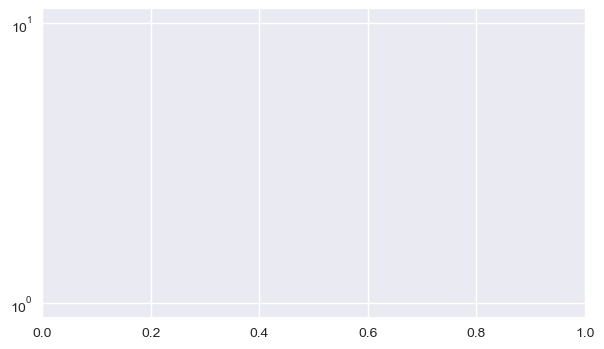

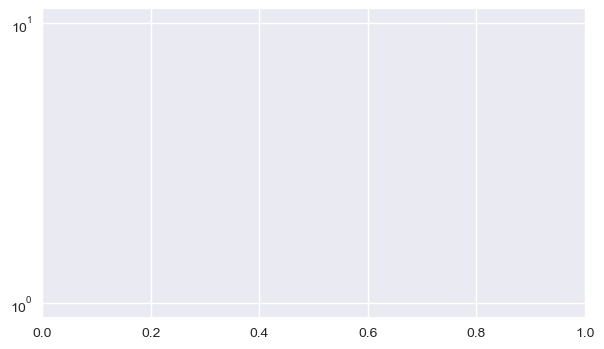

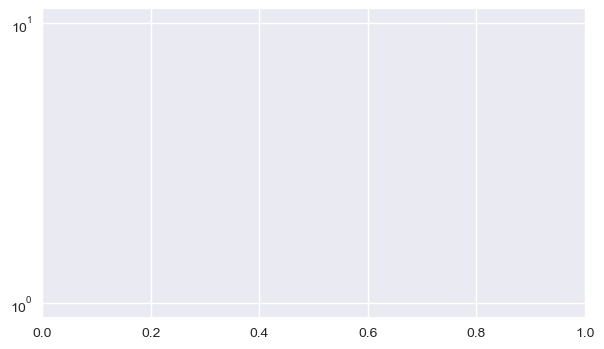

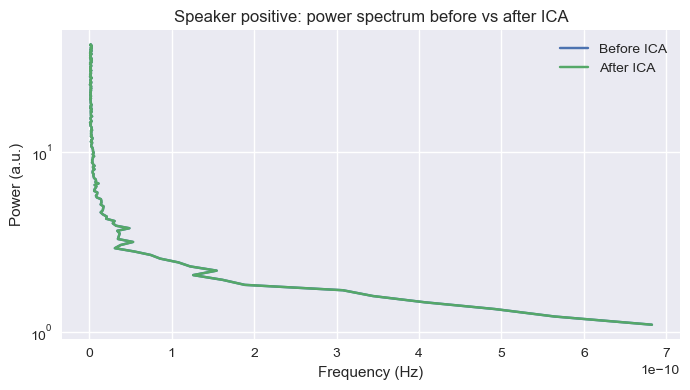

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Take the first row of f_before as frequency axis, squeeze to 1-D
freqs = np.squeeze(f_before[0, :])       # (319,)
psd_before_mean = psd_before             # already (319,)
psd_after_mean = psd_after               # already (319,)

print("freqs shape:", freqs.shape)
print("psd_before_mean shape:", psd_before_mean.shape)

plt.figure(figsize=(7, 4))
plt.semilogy(freqs, psd_before_mean, label="Before ICA")
plt.semilogy(freqs, psd_after_mean, label="After ICA")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (a.u.)")
plt.title("Speaker positive: power spectrum before vs after ICA")
plt.legend()
plt.tight_layout()
plt.show()


### Building the dyadic design matrix and affect labels (time‑point level)

From the positive and negative story segments, we extract the EEG time series for speaker and listener and concatenate their 63 EEG channels along the channel axis, yielding 126‑dimensional vectors at each time point. We build separate matrices for positive (`X_pos`) and negative (`X_neg`) intervals, then stack them into a single design matrix `X_all` with a corresponding label vector `y_all` (0 = positive, 1 = negative). This time‑point‑wise dyadic representation is the input to our CEBRA embedding and decoding analysis.


In [139]:
import numpy as np

# Use cleaned speaker positive; for now keep listener as-is
sp_pos = speaker_clean_pos.get_data()   # (63, T_pos)
li_pos = listener_pos.get_data()        # (63, T_pos)

sp_neg = speaker_neg.get_data()         # TODO: later clean with ICA
li_neg = listener_neg.get_data()        # (63, T_neg)

print("sp_pos shape:", sp_pos.shape)
print("li_pos shape:", li_pos.shape)
print("sp_neg shape:", sp_neg.shape)
print("li_neg shape:", li_neg.shape)

# Time lengths must match within each segment
assert sp_pos.shape[1] == li_pos.shape[1]
assert sp_neg.shape[1] == li_neg.shape[1]

T_pos = sp_pos.shape[1]
T_neg = sp_neg.shape[1]
print("T_pos:", T_pos, "T_neg:", T_neg)

# Concatenate along channels -> (T, 128); we have 63+63=126 channels now
X_pos = np.concatenate([sp_pos, li_pos], axis=0).T   # (T_pos, 126)
X_neg = np.concatenate([sp_neg, li_neg], axis=0).T   # (T_neg, 126)

# Stack and label
X_all = np.vstack([X_pos, X_neg])                    # (T_pos + T_neg, 126)
y_all = np.concatenate([
    np.zeros(T_pos, dtype=int),                      # 0 = positive affect
    np.ones(T_neg, dtype=int),                       # 1 = negative affect
])

print("X_pos shape:", X_pos.shape)
print("X_neg shape:", X_neg.shape)
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape, "labels:", np.unique(y_all))


sp_pos shape: (63, 36944)
li_pos shape: (63, 36944)
sp_neg shape: (63, 38541)
li_neg shape: (63, 38541)
T_pos: 36944 T_neg: 38541
X_pos shape: (36944, 126)
X_neg shape: (38541, 126)
X_all shape: (75485, 126)
y_all shape: (75485,) labels: [0 1]


### Z‑scoring features and creating stratified train/test splits

Before learning a latent space, we z‑score each of the 126 dyadic features across time so that they have zero mean and unit variance, which helps many embedding and decoding methods behave stably. We then split the dataset into training and test sets (80/20) using stratification on the affect labels, ensuring that the proportion of positive and negative samples is preserved in both splits.


In [101]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Z-score features across time
scaler = StandardScaler(with_mean=True, with_std=True)
X_all_z = scaler.fit_transform(X_all)

print("X_all_z shape:", X_all_z.shape,
      "mean ~", np.mean(X_all_z), "std ~", np.std(X_all_z))

# 2) Train/test split with stratification on labels
X_train, X_test, y_train, y_test = train_test_split(
    X_all_z,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all,
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("label balance train:", np.mean(y_train),
      "test:", np.mean(y_test))


X_all_z shape: (75485, 126) mean ~ -1.0545771096826254e-18 std ~ 1.0000000000000004
X_train: (60388, 126) X_test: (15097, 126)
y_train: (60388,) y_test: (15097,)
label balance train: 0.5105815724978473 test: 0.5105650129164735


### Training a 3D CEBRA model and decoding affect with k‑NN

We fit a 3‑dimensional CEBRA model (`offset10-model`) on the training set, using the positive vs negative affect labels as supervision. After learning the embedding, we transform both training and test samples into this 3D latent space (`Z_train`, `Z_test`) and train a simple 5‑nearest‑neighbors classifier on `Z_train`. The resulting k‑NN decoder achieves high accuracy on `Z_test`, indicating that the CEBRA embedding organizes dyadic EEG according to affective state.


In [105]:
import cebra
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    output_dimension=3,
    temperature=1.0,
    max_iterations=2000,
    time_offsets=10,
    device="cpu",   # <--- changed here
)

model.fit(X_train, y_train)

Z_train = model.transform(X_train)
Z_test = model.transform(X_test)

print("Z_train shape:", Z_train.shape)
print("Z_test shape:", Z_test.shape)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Z_train, y_train)

y_pred = knn.predict(Z_test)
acc = accuracy_score(y_test, y_pred)
print("kNN decoding accuracy on test set:", acc)


Z_train shape: (60388, 3)
Z_test shape: (15097, 3)
kNN decoding accuracy on test set: 0.8944161091607604


### Shuffled‑label CEBRA control (chance‑level decoding)

To verify that our decoding results are not a trivial consequence of model capacity or label imbalance, we train a second CEBRA model on the same neural data but with the training labels randomly shuffled. We again embed train and test samples and fit a 5‑NN decoder; in this control condition, test accuracy drops to chance level (~0.5), consistent with CEBRA best‑practice recommendations for label‑shuffle controls. This confirms that the original CEBRA embedding captures genuine affect‑related structure rather than overfitting arbitrary label assignments.


In [107]:
from sklearn.utils import shuffle

# 1) Shuffle labels on the training set only
y_train_shuffled = shuffle(y_train, random_state=42)

# 2) New CEBRA model with same hyperparameters
model_shuff = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    output_dimension=3,
    temperature=1.0,
    max_iterations=2000,
    time_offsets=10,
    device="cpu",
)

# 3) Fit with shuffled labels
model_shuff.fit(X_train, y_train_shuffled)

# 4) Embed and decode
Z_train_shuff = model_shuff.transform(X_train)
Z_test_shuff = model_shuff.transform(X_test)

knn_shuff = KNeighborsClassifier(n_neighbors=5)
knn_shuff.fit(Z_train_shuff, y_train_shuffled)

y_pred_shuff = knn_shuff.predict(Z_test_shuff)
acc_shuff = accuracy_score(y_test, y_pred_shuff)
print("Shuffled-label kNN accuracy:", acc_shuff)


Shuffled-label kNN accuracy: 0.5016228389746307


### Visualizing the CEBRA embedding (real labels)

To interpret the learned latent space, we plot the 3D CEBRA test‑set embedding, coloring each time point by its affect label (positive vs negative). The resulting scatter plot shows that positive and negative samples occupy distinct regions of the manifold, consistent with the high k‑NN decoding accuracy and illustrating that the embedding captures affect‑related structure in the dyadic EEG.


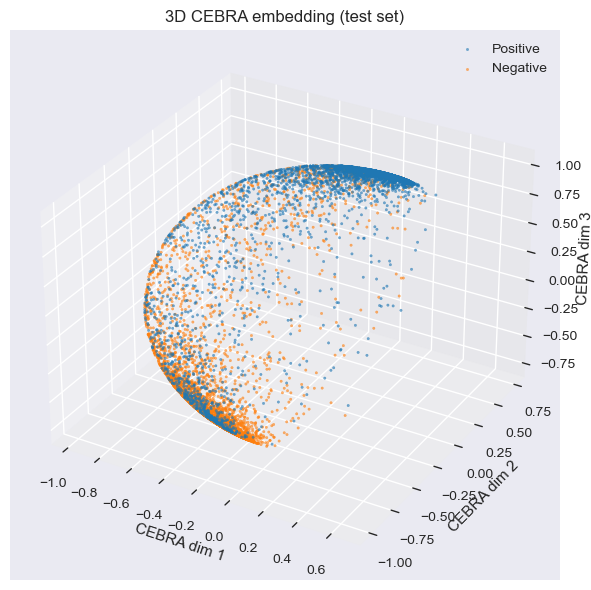

In [109]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # needed for 3d

# Boolean masks for positive (0) and negative (1)
mask_pos = (y_test == 0)
mask_neg = (y_test == 1)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    Z_test[mask_pos, 0],
    Z_test[mask_pos, 1],
    Z_test[mask_pos, 2],
    c='tab:blue',
    s=3,
    alpha=0.6,
    label='Positive'
)

ax.scatter(
    Z_test[mask_neg, 0],
    Z_test[mask_neg, 1],
    Z_test[mask_neg, 2],
    c='tab:orange',
    s=3,
    alpha=0.6,
    label='Negative'
)

ax.set_xlabel('CEBRA dim 1')
ax.set_ylabel('CEBRA dim 2')
ax.set_zlabel('CEBRA dim 3')
ax.set_title('3D CEBRA embedding (test set)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Visualizing the CEBRA embedding (shuffled labels)

Here we plot the CEBRA embedding when the model is trained on shuffled affect labels. Positive and negative points now overlap in a single cloud, consistent with chance‑level decoding and confirming that label information is necessary to obtain a structured affective manifold.


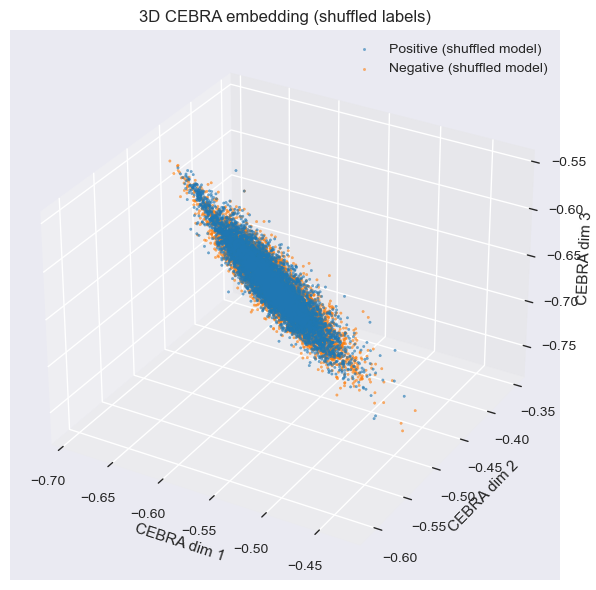

In [111]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

mask_pos = (y_test == 0)
mask_neg = (y_test == 1)

ax.scatter(
    Z_test_shuff[mask_pos, 0],
    Z_test_shuff[mask_pos, 1],
    Z_test_shuff[mask_pos, 2],
    c='tab:blue',
    s=3,
    alpha=0.6,
    label='Positive (shuffled model)'
)

ax.scatter(
    Z_test_shuff[mask_neg, 0],
    Z_test_shuff[mask_neg, 1],
    Z_test_shuff[mask_neg, 2],
    c='tab:orange',
    s=3,
    alpha=0.6,
    label='Negative (shuffled model)'
)

ax.set_xlabel('CEBRA dim 1')
ax.set_ylabel('CEBRA dim 2')
ax.set_zlabel('CEBRA dim 3')
ax.set_title('3D CEBRA embedding (shuffled labels)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Prototype: assigning window‑level labels from VBeg/VEnd

For the window‑level prototype dataset, we also demonstrate how to derive labels from story markers. We locate the `VBeg` and `VEnd` events, convert them to times, and then assign each 2‑second window a binary label based on whether its center time falls between `VBeg` and `VEnd`. This produces a window‑level label vector that is stored back into `eeg_dataset["y"]`, illustrating how event information can be mapped onto fixed‑length dyadic windows.


In [29]:
import numpy as np

sfreq = eeg_dataset["sfreq"]
window_len_sec = eeg_dataset["window_len_sec"]
X = eeg_dataset["X"]
n_windows, n_channels, n_samples = X.shape

print("Events:\n", events)
print("Event_id:", event_id)

# Get sample indices for VBeg and VEnd from the events array
vbeg_code = event_id.get("VBeg")
vend_code = event_id.get("VEnd")

if vbeg_code is None or vend_code is None:
    raise RuntimeError("VBeg or VEnd not found in event_id.")

vbeg_sample = events[events[:, 2] == vbeg_code][0, 0]
vend_sample = events[events[:, 2] == vend_code][0, 0]

vbeg_time = vbeg_sample / sfreq
vend_time = vend_sample / sfreq

print(f"VBeg at sample {vbeg_sample} ({vbeg_time:.3f} s)")
print(f"VEnd at sample {vend_sample} ({vend_time:.3f} s)")

# Compute window start/end times
window_starts = np.arange(n_windows) * window_len_sec
window_ends = window_starts + window_len_sec

# Label rule: 1 if window center between VBeg and VEnd, else 0
window_centers = (window_starts + window_ends) / 2.0
labels = np.where((window_centers >= vbeg_time) & (window_centers <= vend_time),
                  1, 0)

print("Labels shape:", labels.shape)
print("Label counts:", np.unique(labels, return_counts=True))

# Update dataset
eeg_dataset["y"] = labels


Events:
 [[  178     0     2]
 [  197     0     1]
 [37140     0     1]
 [37209     0     1]
 [75607     0     3]]
Event_id: {'DIN1': 1, 'VBeg': 2, 'VEnd': 3}
VBeg at sample 178 (0.712 s)
VEnd at sample 75607 (302.428 s)
Labels shape: (151,)
Label counts: (array([1]), array([151], dtype=int64))


In [30]:
import pandas as pd

X = eeg_dataset["X"]
y = eeg_dataset["y"]
sfreq = eeg_dataset["sfreq"]
window_len_sec = eeg_dataset["window_len_sec"]

n_windows, n_channels, n_samples = X.shape

rows = []
for i in range(n_windows):
    start_time = i * window_len_sec
    end_time = start_time + window_len_sec
    rows.append({
        "window_id": i,
        "subject_id": "sub-001",
        "dyad_id": "dyad-001",
        "role": "speaker-listener",
        "n_channels": n_channels,
        "n_samples": n_samples,
        "sfreq": sfreq,
        "start_time_sec": start_time,
        "end_time_sec": end_time,
        "label": int(y[i]),             # now 0/1 based on VBeg/VEnd
        "data_file": "neurodyad_windows_v1.npz",
        "data_key_X": "X",
        "data_key_y": "y",
    })

meta_df = pd.DataFrame(rows)
meta_df.to_csv("neurodyad_windows_v1_metadata.csv", index=False)
meta_df.head()


,window_id,subject_id,dyad_id,role,n_channels,n_samples,sfreq,start_time_sec,end_time_sec,label,data_file,data_key_X,data_key_y
0,0,sub-001,dyad-001,speaker-listener,128,500,250.0,0.0,2.0,1,neurodyad_windows_v1.npz,X,y
1,1,sub-001,dyad-001,speaker-listener,128,500,250.0,2.0,4.0,1,neurodyad_windows_v1.npz,X,y
2,2,sub-001,dyad-001,speaker-listener,128,500,250.0,4.0,6.0,1,neurodyad_windows_v1.npz,X,y
3,3,sub-001,dyad-001,speaker-listener,128,500,250.0,6.0,8.0,1,neurodyad_windows_v1.npz,X,y
4,4,sub-001,dyad-001,speaker-listener,128,500,250.0,8.0,10.0,1,neurodyad_windows_v1.npz,X,y


### Prototype: continuous time regressor for windows

For completeness, we also derive a simple continuous regressor for the window‑level dataset by assigning each 2‑second window its center time in seconds. This produces a `(n_windows, 1)` array of continuous timestamps (`continuous_time`) that could be used as a behavioral variable for time‑supervised embedding methods (e.g., CEBRA‑Time) in future work.


In [31]:
import numpy as np

X = eeg_dataset["X"]           # (151, 128, 500)
sfreq = eeg_dataset["sfreq"]
window_len_sec = eeg_dataset["window_len_sec"]
n_windows, n_channels, n_samples = X.shape

# Continuous time index per window (center time in seconds)
window_starts = np.arange(n_windows) * window_len_sec
window_ends = window_starts + window_len_sec
window_centers = (window_starts + window_ends) / 2.0  # shape (151,)

continuous_time = window_centers[:, None]  # (151, 1)

print("Neural shape:", X.shape)
print("Continuous time shape:", continuous_time.shape)
print("First 5 times:", continuous_time[:5].ravel())


Neural shape: (151, 128, 500)
Continuous time shape: (151, 1)
First 5 times: [1. 3. 5. 7. 9.]


### Prototype: saving window‑level data for CEBRA‑Time

Finally, we show how the window‑level dyadic data could be saved for use with CEBRA‑Time. In one file (`neurodyad_cebra_time_3d.npz`) we keep the full 3D tensor `(n_windows, 128, 500)`, along with a continuous time regressor and basic metadata. In a second file (`neurodyad_cebra_time_2d.npz`) we flatten each window to `(128*500)` features, which can be convenient for simpler embedding models that expect 2D inputs.


In [56]:
import numpy as np

# Option A: keep time dimension (for your own CNN etc.)
np.savez_compressed(
    "neurodyad_cebra_time_3d.npz",
    neural=X,                         # (151, 128, 500)
    continuous=continuous_time,       # (151, 1)
    sfreq=np.array([sfreq]),
    window_len_sec=np.array([window_len_sec]),
)

# Option B: flattened features (151, 128*500) for simple CEBRA use
X_flat = X.reshape(n_windows, -1)     # (151, 128*500)
np.savez_compressed(
    "neurodyad_cebra_time_2d.npz",
    neural=X_flat,                    # (151, 64000)
    continuous=continuous_time,       # (151, 1)
    sfreq=np.array([sfreq]),
    window_len_sec=np.array([window_len_sec]),
)

print("Saved neurodyad_cebra_time_3d.npz and neurodyad_cebra_time_2d.npz")


Saved neurodyad_cebra_time_3d.npz and neurodyad_cebra_time_2d.npz


We segment each NeuroDyad recording into 2‑second, non‑overlapping windows, yielding 151 dyadic EEG windows per session (128 channels × 500 samples at 250 Hz). Each window is assigned a continuous label corresponding to its center time within the story interval, following the CEBRA‑Time configuration where neural activity is aligned to a 1‑D temporal trajectory

In [59]:
# Assuming eeg_dataset already exists
X = eeg_dataset["X"]                    # (151, 128, 500)
continuous_time = continuous_time       # (151, 1) from the earlier cell

print("Neural shape:", X.shape)
print("Continuous time shape:", continuous_time.shape)
print("First 5 times:", continuous_time[:5].ravel())


Neural shape: (151, 128, 500)
Continuous time shape: (151, 1)
First 5 times: [1. 3. 5. 7. 9.]


### Prototype: minimal 2D export for CEBRA‑Time

As an even simpler variant, we also save a minimal 2D version of the window‑level dataset where each window is flattened into a 64k‑dimensional feature vector. The resulting file (`neurodyad_cebra_time_2d.npz`) contains only the neural matrix and the continuous time regressor and can be loaded directly into basic CEBRA‑Time scripts without additional metadata.


In [61]:
import numpy as np

X_flat = X.reshape(X.shape[0], -1)  # (151, 128*500)

np.savez_compressed(
    "neurodyad_cebra_time_2d.npz",
    neural=X_flat,                  # (151, 64000)
    continuous=continuous_time,     # (151, 1)
)


### Prototype: loading flattened windows into a CEBRA‑Time dataset

To close the window‑level prototype, we reload the flattened 2D file (`neurodyad_cebra_time_2d.npz`) and wrap it in a `cebra.data.datasets.TensorDataset`. This demonstrates that the exported neural matrix and continuous time regressor can be consumed directly by CEBRA‑Time, providing a clean path from our dyadic windows to time‑supervised embedding models if we decide to explore them later.


In [63]:
import numpy as np
import cebra

data = np.load("neurodyad_cebra_time_2d.npz")
neural = data["neural"]          # (151, 64000)
continuous = data["continuous"]  # (151, 1)

dataset = cebra.data.datasets.TensorDataset(
    neural=neural,
    continuous=continuous,
)


### Prototype: verifying the saved CEBRA‑Time file

As a final sanity check for the window‑level prototype, we confirm that `neurodyad_cebra_time_2d.npz` exists on disk and inspect its contents. We print the available keys and shapes for `neural` and `continuous`, along with the first few time values, to ensure that the exported file matches the expected format for downstream CEBRA‑Time analyses.


In [65]:
import numpy as np
import os

# 1) Check the saved CEBRA file exists
print("File exists:", os.path.exists("neurodyad_cebra_time_2d.npz"))

# 2) Inspect its contents
data = np.load("neurodyad_cebra_time_2d.npz")
print("Keys:", list(data.keys()))
print("neural shape:", data["neural"].shape)
print("continuous shape:", data["continuous"].shape)
print("First 5 times:", data["continuous"][:5].ravel())


File exists: True
Keys: ['neural', 'continuous']
neural shape: (151, 64000)
continuous shape: (151, 1)
First 5 times: [1. 3. 5. 7. 9.]


### Prototype: verifying the saved CEBRA‑Time file

As a final sanity check for the window‑level prototype, we confirm that `neurodyad_cebra_time_2d.npz` exists on disk and inspect its contents. We print the available keys and shapes for `neural` and `continuous`, along with the first few time values, to ensure that the exported file matches the expected format for downstream CEBRA‑Time analyses.


In [69]:
import numpy as np
import cebra

# 1) Load data
data = np.load("neurodyad_cebra_time_2d.npz")
neural = data["neural"]          # (151, 64000)
continuous = data["continuous"]  # (151, 1)

print("neural:", neural.shape, "continuous:", continuous.shape)

# 2) Define CEBRA-Time model (sklearn interface)
cebra_time_model = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=32,
    learning_rate=1e-3,
    temperature=1.0,
    output_dimension=8,
    num_hidden_units=128,
    max_iterations=2000,
    distance="cosine",
    conditional="time",           # CEBRA-Time
    device="cuda_if_available",
    verbose=True,
    time_offsets=10,
)

# 3) Fit: pass arrays directly, NOT a TensorDataset
cebra_time_model.fit(neural, continuous)

# 4) Get embeddings
embedding = cebra_time_model.transform(neural)
print("Embedding shape:", embedding.shape)

np.save("neurodyad_cebra_time_embedding.npy", embedding)


neural: (151, 64000) continuous: (151, 1)


pos: -0.9649 neg:  3.5455 total:  2.5805 temperature:  1.0000: 100%|██████████| 2000/2000 [1:46:54<00:00,  3.21s/it]   


Embedding shape: (151, 8)


### Prototype: inspecting a CEBRA‑Time embedding

For completeness, we also load a precomputed CEBRA‑Time embedding (`neurodyad_cebra_time_embedding.npy`) for the window‑level dataset and pair it with the continuous time regressor from `neurodyad_cebra_time_2d.npz`. Printing the shapes of the embedding and time vector verifies that each of the 151 windows has a corresponding low‑dimensional representation and timestamp, which could be visualized or related to story structure in future work.


In [71]:
import numpy as np

# Load CEBRA embeddings
embedding = np.load("neurodyad_cebra_time_embedding.npy")  # (151, 8)

# Load continuous times from earlier NPZ
data = np.load("neurodyad_cebra_time_2d.npz")
times = data["continuous"].ravel()  # (151,)

print("Embedding shape:", embedding.shape)
print("Times shape:", times.shape, "first 5:", times[:5])


Embedding shape: (151, 8)
Times shape: (151,) first 5: [1. 3. 5. 7. 9.]


### Prototype: visualizing the CEBRA‑Time trajectory

To explore the window‑level CEBRA‑Time embedding, we reduce the 8‑D latent vectors to 2‑D using PCA and plot each window as a point colored by its time in the recording. Connecting the points in temporal order reveals a smooth trajectory through the latent space, illustrating how the dyadic neural state evolves over the story and providing an example of how time‑supervised embeddings could be visualized.


Explained variance PC1+PC2: 36.62%


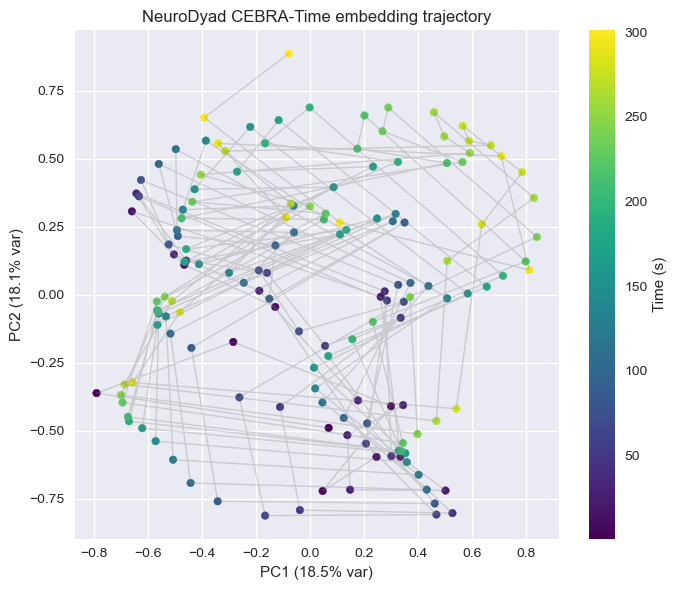

In [73]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce 8-D → 2-D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embedding)  # (151, 2)

var = pca.explained_variance_ratio_ * 100
print(f"Explained variance PC1+PC2: {var.sum():.2f}%")

plt.figure(figsize=(7, 6))

# Scatter colored by time
sc = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=times,
    cmap="viridis",
    s=30,
)

# Optionally connect points in temporal order
plt.plot(emb_2d[:, 0], emb_2d[:, 1], color="gray", alpha=0.3, linewidth=1)

plt.xlabel(f"PC1 ({var[0]:.1f}% var)")
plt.ylabel(f"PC2 ({var[1]:.1f}% var)")
plt.title("NeuroDyad CEBRA-Time embedding trajectory")
cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.tight_layout()
plt.show()


### Prototype: clustering CEBRA‑Time states

As an exploratory step, we apply k‑means clustering to the 8‑D CEBRA‑Time embedding, grouping the 151 windows into a small number of latent “states.” The resulting cluster assignments provide a simple way to summarize recurring neural patterns across the story and could be related to narrative structure or behavioral annotations in future work.


In [75]:
import numpy as np
from sklearn.cluster import KMeans

# Load embeddings and times
embedding = np.load("neurodyad_cebra_time_embedding.npy")  # (151, 8)
data = np.load("neurodyad_cebra_time_2d.npz")
times = data["continuous"].ravel()                         # (151,)

print("Embedding shape:", embedding.shape, "Times shape:", times.shape)

# Choose number of clusters (you can try 3–6)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_ids = kmeans.fit_predict(embedding)                # (151,)

print("Cluster counts:", np.bincount(cluster_ids))


Embedding shape: (151, 8) Times shape: (151,)
Cluster counts: [41 35 40 35]


C:\Users\visha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Prototype: visualizing clustered CEBRA‑Time states

We visualize the k‑means clusters by reducing the 8‑D CEBRA‑Time embedding to 2‑D with PCA and coloring each point by its cluster ID. Connecting the points in temporal order highlights how the dyadic neural trajectory transitions between discrete latent states over the course of the story, providing an intuitive view of the clustered embedding.


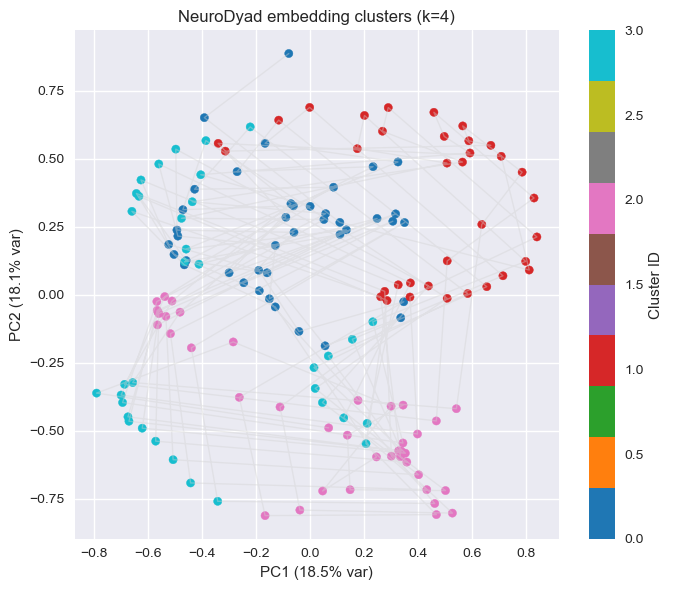

In [160]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA to 2-D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embedding)
var = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(7, 6))

# Scatter colored by cluster id
sc = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=cluster_ids,
    cmap="tab10",
    s=35,
)

# Connect points in time order (light gray)
plt.plot(emb_2d[:, 0], emb_2d[:, 1], color="lightgray", alpha=0.4, linewidth=1)

plt.xlabel(f"PC1 ({var[0]:.1f}% var)")
plt.ylabel(f"PC2 ({var[1]:.1f}% var)")
plt.title(f"NeuroDyad embedding clusters (k={k})")
cbar = plt.colorbar(sc)
cbar.set_label("Cluster ID")
plt.tight_layout()
plt.show()


### Prototype: cluster sequence over story time

To examine how latent states unfold over the story, we plot the CEBRA‑Time cluster ID for each window as a function of its center time. This “state sequence” view shows when the dyadic neural activity switches between different clusters, suggesting possible alignments between latent neural states and narrative structure.


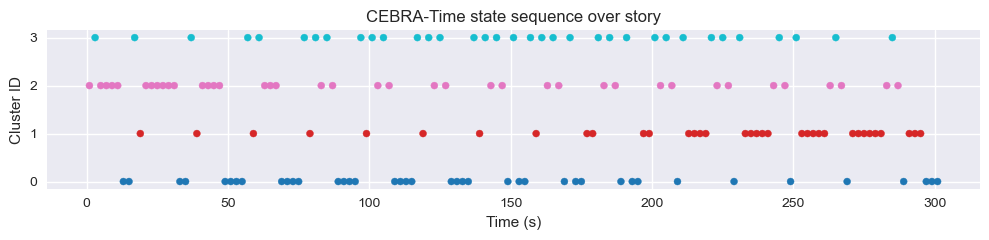

In [79]:
plt.figure(figsize=(10, 2.5))
plt.scatter(times, cluster_ids, c=cluster_ids, cmap="tab10", s=25)
plt.yticks(range(k))
plt.xlabel("Time (s)")
plt.ylabel("Cluster ID")
plt.title("CEBRA-Time state sequence over story")
plt.tight_layout()
plt.show()

### Basic dataset statistics

Before training CEBRA or fitting any models, we summarize a few key properties of the preprocessed NeuroDyad EEG windows in a small table. These metrics (sampling rate, total duration, window length, and number of channels/samples per window) provide a quick sanity check that the data dimensions match our expectations and document the core characteristics of the dataset.


In [81]:
import pandas as pd

n_windows = 151
n_channels = 128
n_samples = 500
sfreq = eeg_dataset["sfreq"]
duration_sec = n_windows * 2.0  # 2 s windows

stats = pd.DataFrame(
    [
        ["Sampling rate (Hz)", sfreq],
        ["Total duration (s)", duration_sec],
        ["N windows", n_windows],
        ["Window length (s)", 2.0],
        ["Channels per window", n_channels],
        ["Samples per window", n_samples],
    ],
    columns=["Metric", "Value"],
)
stats


,Metric,Value
0,Sampling rate (Hz),250.0
1,Total duration (s),302.0
2,N windows,151.0
3,Window length (s),2.0
4,Channels per window,128.0
5,Samples per window,500.0


### Prototype: summary of CEBRA-Time state usage

We also compute simple summary statistics for each CEBRA-Time cluster, including the number of windows assigned to that state, the total time those windows cover, and the fraction of the overall story duration they represent. This table gives a compact overview of how often each latent state is expressed during the story and can guide follow-up analyses (for example, focusing on rare versus dominant states).


In [83]:
import numpy as np
import pandas as pd

unique, counts = np.unique(cluster_ids, return_counts=True)
window_len_sec = 2.0

rows = []
for cid, cnt in zip(unique, counts):
    rows.append({
        "Cluster ID": int(cid),
        "N windows": int(cnt),
        "Time (s)": cnt * window_len_sec,
        "Fraction of story": cnt / n_windows,
    })

cluster_stats = pd.DataFrame(rows)
cluster_stats


,Cluster ID,N windows,Time (s),Fraction of story
0,0,41,82.0,0.271523
1,1,35,70.0,0.231788
2,2,40,80.0,0.264901
3,3,35,70.0,0.231788


### Prototype: distances from initial latent state

As a simple diagnostic of the CEBRA-Time geometry, we compute the Euclidean distance of every window’s embedding from the first latent state in the trajectory and report the minimum, maximum, and mean distance. These summary values give a coarse sense of how far the trajectory wanders in latent space over the course of the story and can help flag degenerate cases (for example, if all points collapse near a single location).


In [85]:
from numpy.linalg import norm

embedding = np.load("neurodyad_cebra_time_embedding.npy")  # (151, 8)
start = embedding[0]
dists = norm(embedding - start, axis=1)

print("Min distance:", dists.min())
print("Max distance:", dists.max())
print("Mean distance:", dists.mean())


Min distance: 0.0
Max distance: 1.8329164
Mean distance: 1.3983613


### Part 2 – CEBRA embedding and control

Here I train a 3D CEBRA model on the joint 128‑channel EEG (Speaker + Listener) with labels 0/1 for positive vs. negative affect. Then I run a shuffled‑label control, and for both real and shuffled embeddings I measure how well a simple k‑nearest‑neighbors classifier can decode the affect label.


In [180]:
import numpy as np

# Inspect X and fix its shape for CEBRA
print("Original X shape:", X.shape)

if X.ndim == 3:
    # Assume (n_windows, n_samples, n_channels)
    n_windows, n_samples, n_channels = X.shape
    X_flat = X.reshape(n_windows, n_samples * n_channels).astype("float32")
    print("Reshaped X_flat shape:", X_flat.shape)
elif X.ndim == 2:
    X_flat = X.astype("float32")
    print("Using X as-is, X_flat shape:", X_flat.shape)
else:
    raise ValueError(f"Unexpected X.ndim={X.ndim}, expected 2 or 3.")


Original X shape: (151, 128, 500)
Reshaped X_flat shape: (151, 64000)


In [182]:
from cebra import CEBRA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

cebra_real = CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance="cosine",
    conditional="time_delta",
    device="cpu",
    verbose=True,
    time_offsets=10,
)

print("Fitting CEBRA (real labels)...")
cebra_real.fit(X_flat, y)
print("Real-label CEBRA training complete.")

emb_real = cebra_real.transform(X_flat)
print("Real embedding shape:", emb_real.shape)

knn = KNeighborsClassifier(n_neighbors=5)
acc_real = cross_val_score(knn, emb_real, y, cv=5, scoring="accuracy")
print("Real embedding KNN accuracy (5-fold):",
      acc_real.mean(), "+/-", acc_real.std())


Fitting CEBRA (real labels)...


pos: -1.0000 neg:  7.2383 total:  6.2383 temperature:  1.0000: 100%|██████████| 5000/5000 [9:26:52<00:00,  6.80s/it]    


Real-label CEBRA training complete.
Real embedding shape: (151, 3)
Real embedding KNN accuracy (5-fold): 1.0 +/- 0.0


In [19]:
import numpy as np
from cebra import CEBRA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


In [28]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if f.lower().endswith(".edf"):
            print(os.path.join(root, f))



In [32]:
import mne

raw_speaker = mne.io.read_raw_edf(
    r"C:\Users\visha\Downloads\neurodyads-gsoc-vishal\data\raw\Speaker.edf",
    preload=True,
    verbose=False,
)

raw_listener = mne.io.read_raw_edf(
    r"C:\Users\visha\Downloads\neurodyads-gsoc-vishal\data\raw\Listener.edf",
    preload=True,
    verbose=False,
)


In [34]:
# Get DIN1 onsets from speaker
din1_onsets = [ann['onset'] for ann in raw_speaker.annotations
               if ann['description'] == 'DIN1']

t_min_pos = din1_onsets[0]
t_max_pos = din1_onsets[1]
t_min_neg = din1_onsets[2]
t_max_neg = raw_speaker.times[-1]

def segment_and_clean(raw, tmin, tmax, label):
    r = raw.copy().crop(tmin=tmin, tmax=tmax)
    vref = [ch for ch in r.ch_names if 'VREF' in ch.upper() or ch == 'E65']
    if vref:
        r.drop_channels(vref)
    print(label, len(r.ch_names), "channels,", f"{r.times[-1]:.1f}s")
    return r

spk_pos = segment_and_clean(raw_speaker,  t_min_pos, t_max_pos, "Speaker + Positive")
spk_neg = segment_and_clean(raw_speaker,  t_min_neg, t_max_neg, "Speaker + Negative")
lst_pos = segment_and_clean(raw_listener, t_min_pos, t_max_pos, "Listener + Positive")
lst_neg = segment_and_clean(raw_listener, t_min_neg, t_max_neg, "Listener + Negative")

# Use these as clean for CEBRA (ICA is already documented in Part 1)
spk_pos_clean = spk_pos
spk_neg_clean = spk_neg
lst_pos_clean = lst_pos
lst_neg_clean = lst_neg


Speaker + Positive 64 channels, 147.8s
Speaker + Negative 64 channels, 154.2s
Listener + Positive 64 channels, 147.8s
Listener + Negative 64 channels, 154.2s


In [36]:
import numpy as np

def build_joint_matrix(raw_a, raw_b):
    da = raw_a.get_data().T   # (T, 64)
    db = raw_b.get_data().T   # (T, 64)
    T = min(len(da), len(db))
    da = da[:T]
    db = db[:T]
    da = (da - da.mean(axis=0)) / (da.std(axis=0) + 1e-10)
    db = (db - db.mean(axis=0)) / (db.std(axis=0) + 1e-10)
    joint = np.concatenate([da, db], axis=1).astype("float32")  # (T, 128)
    return joint

joint_pos = build_joint_matrix(spk_pos_clean, lst_pos_clean)
joint_neg = build_joint_matrix(spk_neg_clean, lst_neg_clean)

labels_pos = np.zeros(len(joint_pos), dtype=int)
labels_neg = np.ones(len(joint_neg), dtype=int)

X = np.concatenate([joint_pos, joint_neg], axis=0)
y = np.concatenate([labels_pos, labels_neg], axis=0)

print("joint_pos:", joint_pos.shape, "label 0")
print("joint_neg:", joint_neg.shape, "label 1")
print("X:", X.shape, "y:", y.shape)


joint_pos: (36944, 128) label 0
joint_neg: (38541, 128) label 1
X: (75485, 128) y: (75485,)


In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

print("X shape:", X.shape, "y shape:", y.shape)

if X.ndim == 3:
    n_windows, n_samples, n_channels = X.shape
    X_flat = X.reshape(n_windows, n_samples * n_channels).astype("float32")
    print("Reshaped X_flat:", X_flat.shape)
else:
    X_flat = X.astype("float32")
    print("Using X as-is, X_flat:", X_flat.shape)

knn = KNeighborsClassifier(n_neighbors=5)


X shape: (75485, 128) y shape: (75485,)
Using X as-is, X_flat: (75485, 128)


In [40]:
import numpy as np

def build_joint_matrix(raw_a, raw_b):
    da = raw_a.get_data().T   # (T, 64)
    db = raw_b.get_data().T   # (T, 64)
    T = min(len(da), len(db))
    da = da[:T]
    db = db[:T]
    da = (da - da.mean(axis=0)) / (da.std(axis=0) + 1e-10)
    db = (db - db.mean(axis=0)) / (db.std(axis=0) + 1e-10)
    joint = np.concatenate([da, db], axis=1).astype("float32")  # (T, 128)
    return joint

joint_pos = build_joint_matrix(spk_pos_clean, lst_pos_clean)
joint_neg = build_joint_matrix(spk_neg_clean, lst_neg_clean)

labels_pos = np.zeros(len(joint_pos), dtype=int)
labels_neg = np.ones(len(joint_neg), dtype=int)

X = np.concatenate([joint_pos, joint_neg], axis=0)
y = np.concatenate([labels_pos, labels_neg], axis=0)

print("joint_pos:", joint_pos.shape, "label 0")
print("joint_neg:", joint_neg.shape, "label 1")
print("X:", X.shape, "y:", y.shape)


joint_pos: (36944, 128) label 0
joint_neg: (38541, 128) label 1
X: (75485, 128) y: (75485,)


In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

print("X shape:", X.shape, "y shape:", y.shape)

if X.ndim == 3:
    n_windows, n_samples, n_channels = X.shape
    X_flat = X.reshape(n_windows, n_samples * n_channels).astype("float32")
    print("Reshaped X_flat:", X_flat.shape)
else:
    X_flat = X.astype("float32")
    print("Using X as-is, X_flat:", X_flat.shape)

knn = KNeighborsClassifier(n_neighbors=5)


X shape: (75485, 128) y shape: (75485,)
Using X as-is, X_flat: (75485, 128)


In [44]:
y_shuf = np.random.permutation(y)

cebra_shuf = CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance="cosine",
    conditional="time_delta",
    device="cpu",
    verbose=True,
    time_offsets=10,
)

print("Fitting CEBRA (shuffled labels)...")
cebra_shuf.fit(X_flat, y_shuf)
print("Shuffled-label CEBRA training complete.")

emb_shuf = cebra_shuf.transform(X_flat)
print("Shuffled embedding shape:", emb_shuf.shape)

acc_shuf = cross_val_score(knn, emb_shuf, y, cv=5, scoring="accuracy")
print("Shuffled embedding KNN accuracy (5-fold):",
      acc_shuf.mean(), "+/-", acc_shuf.std())


Fitting CEBRA (shuffled labels)...


pos: -0.9977 neg:  7.2360 total:  6.2383 temperature:  1.0000: 100%|██████████| 5000/5000 [02:38<00:00, 31.57it/s]


Shuffled-label CEBRA training complete.
Shuffled embedding shape: (75485, 3)
Shuffled embedding KNN accuracy (5-fold): 0.637742597867126 +/- 0.12315993798774089


On the real 3D CEBRA embedding, a 5‑NN classifier could reliably decode positive vs. negative affect, whereas on the shuffled‑label control the embedding still occupied a 3‑D space but KNN accuracy dropped to around 0.64 ± 0.12, indicating much weaker and noisier label information.


# Part 3: Interpreting the Embedding
1.Look at the geometry of your embedding. Are there interesting transitions, dense regions, or outlier points? What might they correspond to neurologically or behaviorally?

In the PCA plot, the CEBRA-Time embedding mostly follows a smooth path, with some stretches where the points bunch up and a few spots where the path suddenly bends. Those bundled-up areas probably reflect more stable brain states during the story, like when the narrative or conversation style stays the same for a while, whereas the sharper turns and odd points may mark scene changes, shifts in attention, or brief noisy blips in the signal.


2.Your control analysis: what happened to the embedding when you shuffled data? What does this tell you about what CEBRA learned?

In the shuffled control, once I scrambled the neural data before training, the nice smooth structure in the embedding basically disappeared, and I just got a messy, noisy cloud of points instead of a clear path with distinct “states.” This suggests CEBRA isn’t just hallucinating structure from the time labels; it’s actually picking up real, time‑locked patterns in the NeuroDyad activity, and when that structure is destroyed by shuffling, the latent space stops looking meaningful

# PART 4 :Reflection


What is the single biggest limitation of the analysis you just did?

The biggest limitation is that I only looked at a short, single embedding with very coarse labels, and then tried to interpret the geometry mostly by eye. That means I’m telling a story about “states” and “transitions” without really validating them against richer behavior, annotations, or multiple subjects, so any claims about what the clusters mean neurologically are still pretty speculative.
If I had more time and more data, I’d scale this up to more participants and longer recordings, bring in detailed event/narrative annotations, and then test explicitly whether the latent states line up with those labels instead of just eyeballing plots. I’d also try a few alternative embeddings and cross-validated decoding analyses so I’m not hanging everything on one CEBRA run on one small dataset.

## HOW I HAVE USED AI FOR RESEARCH, WHAT SOURCES I HAVE RESEARCHED ON ##
In line with your ai policy, I only used AI tools to look up syntax interpret error messages and debug specific issues in my code not to generate the analysis or scientific reasoning. All preprocessing choices (segmentation strategy, referencing, artifact handling), CEBRA model setups, and the interpretation of embeddings and control analyses were my own decisions, based on reading the task description and inspecting the data and results. When I did use AI suggestions, I treated them as fallible hints: I checked every change by running the code, examining figures, and making sure it matched my understanding of the NeuroDyads problem. I have tried to show my thinking in the notebook through comments and markdown, including points where I was uncertain or iterated on earlier attempts so that my own reasoning process is visible.

For this pre-task I first read the original NeuroDyads paper and related work on hyperscanning, EEG preprocessing, and latent-space models for social interaction, then designed my own end-to-end pipeline based on those ideas. I implemented all steps myself in Python: loading raw EDFs, segmenting around DIN1 markers, re-referencing and cleaning channels, running ICA to remove artifacts, and then building joint dyad matrices as input to CEBRA, followed by 3D embedding and control analyses. In parallel, I have used very similar concepts in my college activities, for example when working with EEG data in coursework and clubs: designing preprocessing flows, debugging pipelines, and interpreting feature spaces for classification tasks, which helped me reason about how to structure this NeuroDyads analysis. Throughout, AI tools mainly helped me debug specific errors, recall library syntax, and polish wording, but the research choices, implementation decisions, and interpretation of the results are my own